In [1]:
!pip install -q accelerate evaluate transformers torchvision

In [2]:
!pip install datasets==5.0.0

### Model Downloading and Loading

In [3]:
import torch
from transformers import AutoModel, AutoProcessor

model_name = "../content/drive/MyDrive/siglip_model"
model = AutoModel.from_pretrained(model_name)

model_name = "google/siglip-base-patch16-224"
processor = AutoProcessor.from_pretrained(model_name)

print("model loaded successfully.")
model

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model loaded successfully.


SiglipModel(
  (text_model): SiglipTextModel(
    (embeddings): SiglipTextEmbeddings(
      (token_embedding): Embedding(32000, 768)
      (position_embedding): Embedding(64, 768)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-11): 12 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): GELUTanh()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, 

### Dataset downloading from hugging face

In [4]:
from datasets import load_dataset, load_from_disk

# first time loaded from hugging face
# cancer_dataset = load_dataset("1aurent/NCT-CRC-HE",split= "CRC_VAL_HE_7K")

# loading the dataset from local
cancer_dataset = load_from_disk("../content/drive/MyDrive/Colab Notebooks/dataset")
cancer_dataset


Dataset({
    features: ['image', 'label'],
    num_rows: 7180
})

In [4]:
cancer_dataset.save_to_disk("../content/drive/MyDrive/siglip_model/dataset")
model.save_pretrained("../content/drive/MyDrive/siglip_model")

Saving the dataset (0/3 shards):   0%|          | 0/7180 [00:00<?, ? examples/s]

KeyboardInterrupt: 

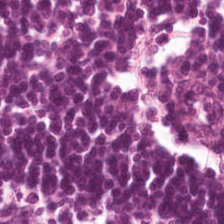

In [5]:
cancer_dataset["image"][2131]

In [6]:
dataset = cancer_dataset.train_test_split(train_size = 6000, test_size = 1000,shuffle = True, seed = 42)
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 6000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})

In [7]:
raw_val = dataset["test"]
raw_val

Dataset({
    features: ['image', 'label'],
    num_rows: 1000
})

## Preprocessing of dataset

In [8]:
from torchvision import transforms

In [9]:
std = processor.image_processor.image_std
mean = processor.image_processor.image_mean
std,mean

((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

In [10]:
classes = dataset["train"].features["label"].names

In [11]:
img_transformer = transforms.Compose([
    transforms.Resize((224,224), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean = mean, std = std)
])

def preprocess(examples):
  pixel_values = [img_transformer(img.convert("RGB")) for img in examples["image"]]
  labels = [classes[label] for label in examples["label"]]

  tokens = processor.tokenizer(labels,  max_length = 64, padding = "max_length", truncation = True, return_attention_mask = True)

  tokens["pixel_values"] = pixel_values
  return tokens


In [12]:
data = dataset.map(preprocess, batched = True, remove_columns = ["image", "label"])
data.set_format(type = "torch", columns  = ["pixel_values", "input_ids", "attention_mask"])
data

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'pixel_values'],
        num_rows: 6000
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'pixel_values'],
        num_rows: 1000
    })
})

In [13]:
data["train"]

Dataset({
    features: ['input_ids', 'attention_mask', 'pixel_values'],
    num_rows: 6000
})

### Data collator

In [14]:
def collate_fn(examples):
    return {
        "pixel_values":   torch.stack([ex["pixel_values"]   for ex in examples]),
        "input_ids":      torch.stack([ex["input_ids"]      for ex in examples]),
        "attention_mask": torch.stack([ex["attention_mask"] for ex in examples]),
        "return_loss":    True,
    }

In [15]:
data["train"][0]

{'input_ids': tensor([ 262, 5583,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1]),
 'attention_mask': tensor([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'pixel_values': tensor([[[-0.2863,  0.2235,  0.5922,  ...,  0.6235,  0.5843,  0.8824],
          [-0.0902,  0.2235,  0.4824,  ...,  0.7490,  0.7020,  0.7961],
          [ 0.1216,  0.3333,  0.4980,  ...,  0.6471,  0.7490,  0.7725],
          ...,
          [ 0.6471,  0.6863,  0.8196,  ...,  0.8118,  0.8588,

In [18]:
label_loader = DataLoader(true_labels, batch_size = 64, shuffle = False)
for i in label_loader:
  print(i)

tensor([8, 3, 2, 6, 5, 6, 8, 2, 8, 6, 0, 2, 0, 0, 7, 0, 8, 1, 3, 8, 8, 6, 0, 8,
        0, 0, 0, 3, 6, 1, 1, 4, 6, 4, 8, 0, 1, 8, 0, 6, 1, 8, 0, 3, 8, 0, 6, 5,
        2, 5, 6, 0, 4, 6, 4, 6, 1, 0, 3, 4, 8, 1, 1, 8], device='cuda:0')
tensor([8, 8, 0, 4, 8, 6, 1, 3, 6, 0, 0, 0, 8, 1, 4, 3, 8, 4, 6, 0, 4, 3, 4, 2,
        1, 6, 3, 4, 0, 5, 7, 5, 6, 6, 8, 2, 0, 8, 0, 3, 0, 2, 0, 1, 5, 4, 8, 4,
        3, 3, 2, 5, 3, 8, 8, 1, 5, 8, 0, 8, 8, 4, 2, 1], device='cuda:0')
tensor([0, 4, 4, 4, 6, 8, 3, 1, 5, 3, 6, 7, 8, 0, 8, 4, 1, 8, 4, 0, 2, 8, 7, 0,
        0, 1, 3, 6, 5, 3, 6, 0, 6, 0, 6, 8, 7, 8, 8, 4, 8, 1, 8, 3, 8, 6, 8, 4,
        8, 6, 1, 4, 1, 4, 5, 5, 0, 0, 4, 4, 1, 5, 0, 4], device='cuda:0')
tensor([1, 4, 4, 3, 0, 7, 8, 6, 3, 3, 6, 6, 0, 0, 5, 2, 0, 8, 4, 6, 0, 6, 8, 0,
        4, 0, 8, 3, 7, 0, 8, 8, 0, 8, 8, 6, 0, 0, 4, 0, 0, 1, 0, 2, 3, 8, 0, 5,
        1, 1, 1, 4, 4, 0, 6, 0, 1, 0, 8, 6, 3, 1, 0, 0], device='cuda:0')
tensor([8, 7, 4, 8, 3, 6, 2, 8, 0, 0, 4, 1, 4, 4, 8, 7, 6, 1, 4,

In [19]:
true_labels[:64]

tensor([8, 3, 2, 6, 5, 6, 8, 2, 8, 6, 0, 2, 0, 0, 7, 0, 8, 1, 3, 8, 8, 6, 0, 8,
        0, 0, 0, 3, 6, 1, 1, 4, 6, 4, 8, 0, 1, 8, 0, 6, 1, 8, 0, 3, 8, 0, 6, 5,
        2, 5, 6, 0, 4, 6, 4, 6, 1, 0, 3, 4, 8, 1, 1, 8], device='cuda:0')

In [21]:
criterion = torch.nn.CrossEntropyLoss()

In [34]:
import evaluate
from torch.utils.data import DataLoader

def image_collate_fn(batch):
    return batch
device  =  "cuda" if torch.cuda.is_available() else "cpu"
true_labels = torch.tensor(raw_val["label"],device = device)
test_loader = DataLoader(
    raw_val["image"],
    batch_size = 64,
    shuffle = False,
    collate_fn = image_collate_fn
)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
def predict(model, test_loader):
  model = model.to(device)
  model.eval()
  total_loss = 0
  all_preds = []
  for batch,(images,labels)  in enumerate(zip(test_loader, label_loader)):
    inputs = processor(text = classes,
                       images = images,
                       padding = "max_length",
                       return_tensors = "pt"
                       ).to(device)

    with torch.no_grad():
        output = model(**inputs)
        loss = criterion(output.logits_per_image,labels).item()
        total_loss += loss
        if  batch % 2 == 0:
          print(f"Batch : {batch}, loss is : {total_loss}")
    predictions = output.logits_per_image.argmax( dim = 1)
    all_preds.extend(predictions.cpu().numpy())
  return all_preds

def score(preds):
  acc_score = accuracy_metric.compute(predictions=preds,references = true_labels)["accuracy"]
  # print(acc_score)
  f1_score = f1_metric.compute(predictions = preds,references=true_labels, average="weighted")["f1"]
  # print(f1_score)
  return acc_score, f1_score

## Results before Model finetuning

In [25]:
preds = predict(model,test_loader)
acc, f1 = score(preds)
print(f"Results before fine tuning : accuracy : {acc}, f1-score : {f1}")

Batch : 0, loss is : 6.547978401184082
Batch : 2, loss is : 17.0387225151062
Batch : 4, loss is : 28.327073574066162
Batch : 6, loss is : 40.148118019104004
Batch : 8, loss is : 50.74242401123047
Batch : 10, loss is : 62.00088596343994
Batch : 12, loss is : 72.71081876754761
Batch : 14, loss is : 83.28713512420654
Results before fine tuning : accuracy : 0.145, f1-score : 0.05181314241646428


## Model Training Arguments

In [26]:
from transformers import TrainingArguments

training_args = TrainingArguments(output_dir = "../content/drive/MyDrive/siglip_model",
                                  num_train_epochs = 5,
                                  per_device_train_batch_size = 64,
                                  learning_rate = 1e-5,
                                  warmup_steps = 50,
                                  weight_decay = 0.01,
                                  lr_scheduler_type = "cosine",
                                  fp16 = torch.cuda.is_available(),
                                  save_strategy = "epoch",
                                  logging_steps = 20,
                                  eval_strategy = "epoch"
                                  )

In [27]:
model

SiglipModel(
  (text_model): SiglipTextModel(
    (embeddings): SiglipTextEmbeddings(
      (token_embedding): Embedding(32000, 768)
      (position_embedding): Embedding(64, 768)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-11): 12 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): GELUTanh()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, 

In [28]:
for params in model.parameters():
  params.requires_grad = False

for params in model.vision_model.encoder.layers[-4:].parameters():
  params.requires_grad = True

for params in model.vision_model.head.mlp.parameters():
  params.requires_grad = True


In [29]:
trainable = sum(params.numel() for params in model.parameters() if params.requires_grad)
total = sum(params.numel() for params in model.parameters())
trainable, total

(33073920, 203155970)

In [30]:
from transformers import Trainer

trainer = Trainer(model,
                  training_args,
                  train_dataset = data["train"],
                  eval_dataset = data["test"],
                  data_collator = collate_fn
                  )

In [31]:
import torch
import torchvision
import datasets

print(torch.__version__)
print(torchvision.__version__)
print(datasets.__version__)

2.11.0+cu128
0.26.0+cu128
5.0.0


In [32]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,3.558200,2.918151
2,3.303302,2.392564
3,3.215981,2.408504
4,3.219248,2.297106
5,3.196720,2.337681


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=470, training_loss=3.856230829117146, metrics={'train_runtime': 2202.026, 'train_samples_per_second': 13.624, 'train_steps_per_second': 0.213, 'total_flos': 2054940940800000.0, 'train_loss': 3.856230829117146, 'epoch': 5.0})

In [38]:
trainer.save_model()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [39]:
ft_model = AutoModel.from_pretrained(training_args.output_dir)
preds = predict(ft_model,test_loader)
acc, f1 = score(preds)
print(f"Results After fine tuning : accuracy : {acc:.1%}, f1-score : {f1}")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Batch : 0, loss is : 3.520394802093506
Batch : 2, loss is : 9.528800010681152
Batch : 4, loss is : 15.77559781074524
Batch : 6, loss is : 22.006235122680664
Batch : 8, loss is : 27.838871955871582
Batch : 10, loss is : 34.37358736991882
Batch : 12, loss is : 40.27323651313782
Batch : 14, loss is : 45.80282020568848
Results After fine tuning : accuracy : 25.3%, f1-score : 0.14954652177517028
